In [ ]:
# Importar las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

try:
    df = pd.read_csv('BBDD.csv')
except FileNotFoundError:
    print("Error: El archivo 'BBDD.csv' no se encontró. Por favor, verifica la ruta.")
    # Para continuar, creamos un dataframe vacío. Reemplázalo con tu carga de datos.
    df = pd.DataFrame() 

# Mostrar las primeras 5 filas para una primera impresión
print("Primeras 5 filas del dataset:")
print(df.head())

# Obtener un resumen técnico del DataFrame
print("\nInformación general del dataset (tipos de datos y nulos):")
print(df.info())

Primeras 5 filas del dataset:
    Año                         Programa SDA Código de proyecto  \
0  2025        Risk Processes Transformation          SDA-65412   
1  2025         NGA & Differential Analytics          SDA-10398   
2  2024           Core Banking Modernization          SDA-44734   
3  2025           Digital Payments Evolution          SDA-70415   
4  2025  Client Solutions & Digital Channels          SDA-75809   

                                Proyecto Dominio     Plan estratégico local  \
0          Risk Data Transformación Perú     RIC     Renovación Tecnológica   
1           Modelo de Scoring para Pymes     ENG  Impulso Digital Perú 2025   
2  Renovación de Plataforma de Préstamos     RIC     Renovación Tecnológica   
3      Pagos Transfronterizos para Pymes     CIB  Impulso Digital Perú 2025   
4      Personalización de Ofertas en App     CCS     Foco en Captación 2025   

  Country Priority              Tipología Estado de Proyecto Desarrollo de SW  \
0          

In [14]:
# --- Acción 1: Convertir las Fechas ---
print("\n--- Ejecutando Acción 1: Conversión de Fechas ---")

date_columns = [
    'Fecha de inicio de ejecución', 
    'Fecha fin de ejecución', 
    'Fecha pase a producción', 
    'Fecha En manos del cliente'
]

# Se convierten las columnas de texto a un formato de fecha real (datetime)
for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y', errors='coerce')

print("Verificación de los nuevos tipos de datos (Dtypes):")
print(df.info())


--- Ejecutando Acción 1: Conversión de Fechas ---
Verificación de los nuevos tipos de datos (Dtypes):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Año                                247 non-null    int64         
 1   Programa SDA                       247 non-null    object        
 2   Código de proyecto                 247 non-null    object        
 3   Proyecto                           247 non-null    object        
 4   Dominio                            247 non-null    object        
 5   Plan estratégico local             247 non-null    object        
 6   Country Priority                   247 non-null    object        
 7   Tipología                          247 non-null    object        
 8   Estado de Proyecto                 247 non-null    object        
 9   Desarr

In [23]:
# Filtrar proyectos según los criterios solicitados
df_filtrado = df[
    (df['Estado de Proyecto'] != 'Ongoing') &
    (df['Desarrollo de SW'] == 'Sí') &
    (df['Excepción del cálculo'] == 'No')
].copy()

print(f"Tamaño del dataset tras el filtro: {df_filtrado.shape[0]} filas.")
print(f"Este nuevo dataset ('df_finalizado') será el que usaremos para el modelo.")

Tamaño del dataset tras el filtro: 154 filas.
Este nuevo dataset ('df_finalizado') será el que usaremos para el modelo.


In [17]:
print("--- Ejecutando Acción 3: Verificación de Consistencia Categórica ---")

# 1. Definir las columnas a revisar
categorical_cols_check = [
    'Dominio', 
    'Tipología', 
    'Plan estratégico local', 
    'Complejidad técnica inicial',
]

# 2. Iterar y mostrar los valores únicos de cada una
for col in categorical_cols_check:
    print(f"\n--- Valores Únicos en la Columna: '{col}' ---")
    print(df_filtrado[col].value_counts())
    print("-" * 40)

--- Ejecutando Acción 3: Verificación de Consistencia Categórica ---

--- Valores Únicos en la Columna: 'Dominio' ---
Dominio
ENG    37
CIB    33
CCS    29
RIC    19
GRM    15
T&C    14
FIN     7
Name: count, dtype: int64
----------------------------------------

--- Valores Únicos en la Columna: 'Tipología' ---
Tipología
Iterativo/Incremental    81
Secuencial               73
Name: count, dtype: int64
----------------------------------------

--- Valores Únicos en la Columna: 'Plan estratégico local' ---
Plan estratégico local
Renovación Tecnológica           37
Eficiencia y Sostenibilidad      31
Crecimiento en Banca Empresas    20
Impulso Digital Perú 2021         8
Impulso Digital Perú 2024         7
Impulso Digital Perú 2022         7
Impulso Digital Perú 2023         6
Foco en Captación 2020            6
Foco en Captación 2022            5
Impulso Digital Perú 2020         5
Foco en Captación 2023            4
Foco en Captación 2021            4
Foco en Captación 2024            

Generando Gráfico 1: Histograma del Time to Market...


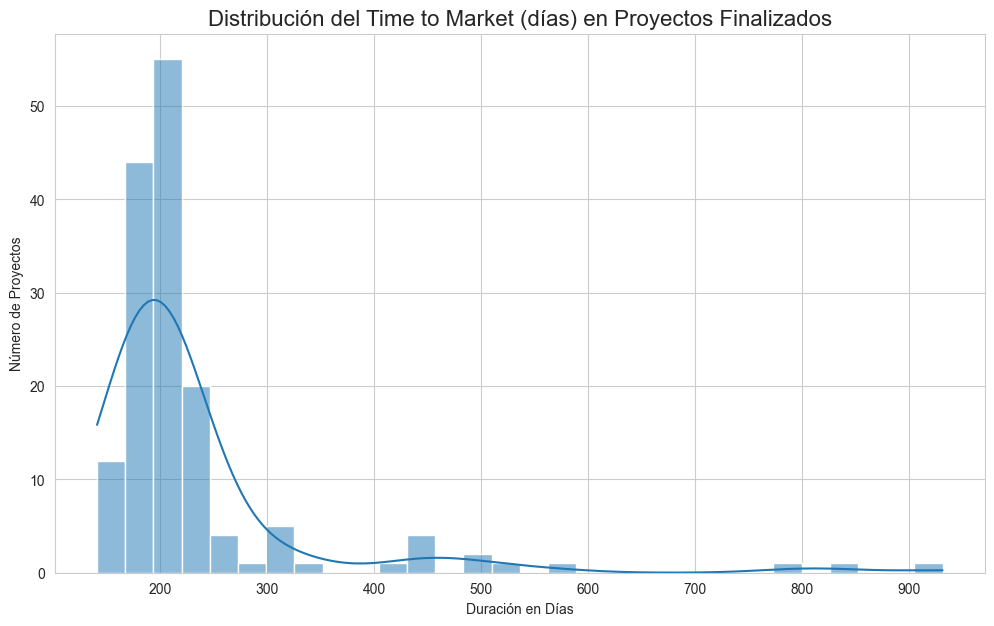

In [22]:
# --- Gráfico 1: Distribución del Time to Market ---
print("Generando Gráfico 1: Histograma del Time to Market...")
plt.figure(figsize=(12, 7))
sns.histplot(df_filtrado['Time to market (días)'].dropna(), kde=True, bins=30)
plt.title('Distribución del Time to Market (días) en Proyectos Finalizados', fontsize=16)
plt.xlabel('Duración en Días')
plt.ylabel('Número de Proyectos')
plt.show()



Generando Gráfico 2: Distribución de Variables Categóricas...


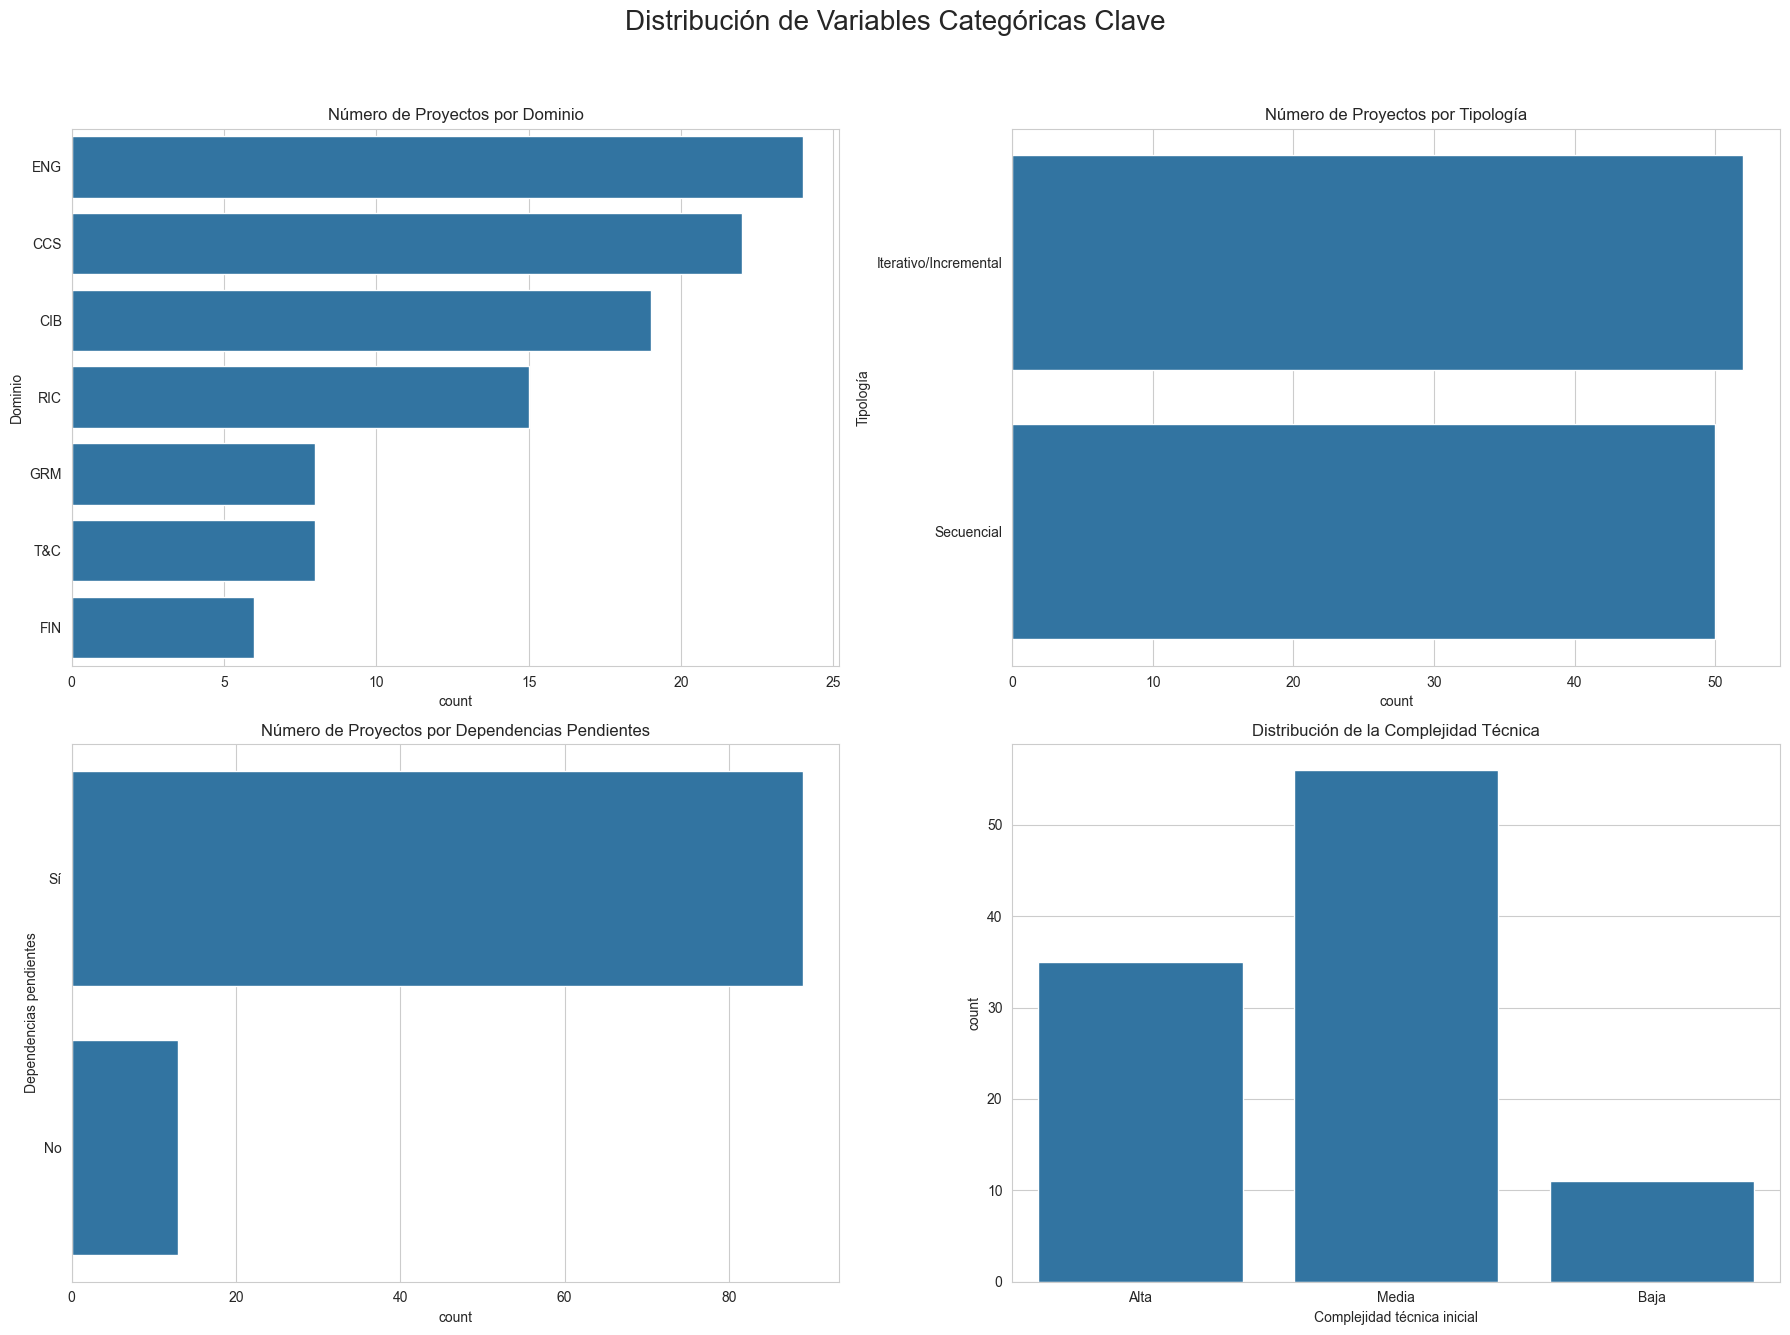

In [30]:
# --- Gráfico 2: Distribución de Variables Categóricas Clave ---
print("\nGenerando Gráfico 2: Distribución de Variables Categóricas...")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Distribución de Variables Categóricas Clave', fontsize=20)

sns.countplot(ax=axes[0, 0], y=df_filtrado['Dominio'], order=df_filtrado['Dominio'].value_counts().index)
axes[0, 0].set_title('Número de Proyectos por Dominio')

sns.countplot(ax=axes[0, 1], y=df_filtrado['Tipología'], order=df_filtrado['Tipología'].value_counts().index)
axes[0, 1].set_title('Número de Proyectos por Tipología')


sns.countplot(ax=axes[1, 0], y=df_filtrado['Dependencias pendientes'], order=df_filtrado['Dependencias pendientes'].value_counts().index)
axes[1, 0].set_title('Número de Proyectos por Dependencias Pendientes')

sns.countplot(ax=axes[1, 1], x=df_filtrado['Complejidad técnica inicial'])
axes[1, 1].set_title('Distribución de la Complejidad Técnica')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generando gráfico: Número de Proyectos por Número de Dependencias Pendientes...


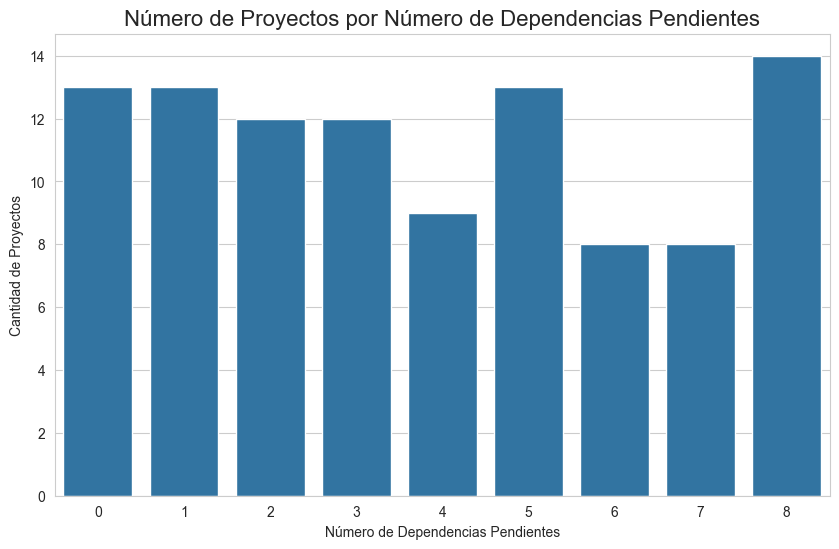

In [7]:
# --- Gráfico: Número de Proyectos por Número de Dependencias Pendientes ---
print("Generando gráfico: Número de Proyectos por Número de Dependencias Pendientes...")
plt.figure(figsize=(10, 6))
sns.countplot(x='Número de dependencias pendientes', data=df_filtrado, order=sorted(df_filtrado['Número de dependencias pendientes'].unique()))
plt.title('Número de Proyectos por Número de Dependencias Pendientes', fontsize=16)
plt.xlabel('Número de Dependencias Pendientes')
plt.ylabel('Cantidad de Proyectos')
plt.show()

Generando Gráfico 3: Boxplot de Time to Market por Dominio...


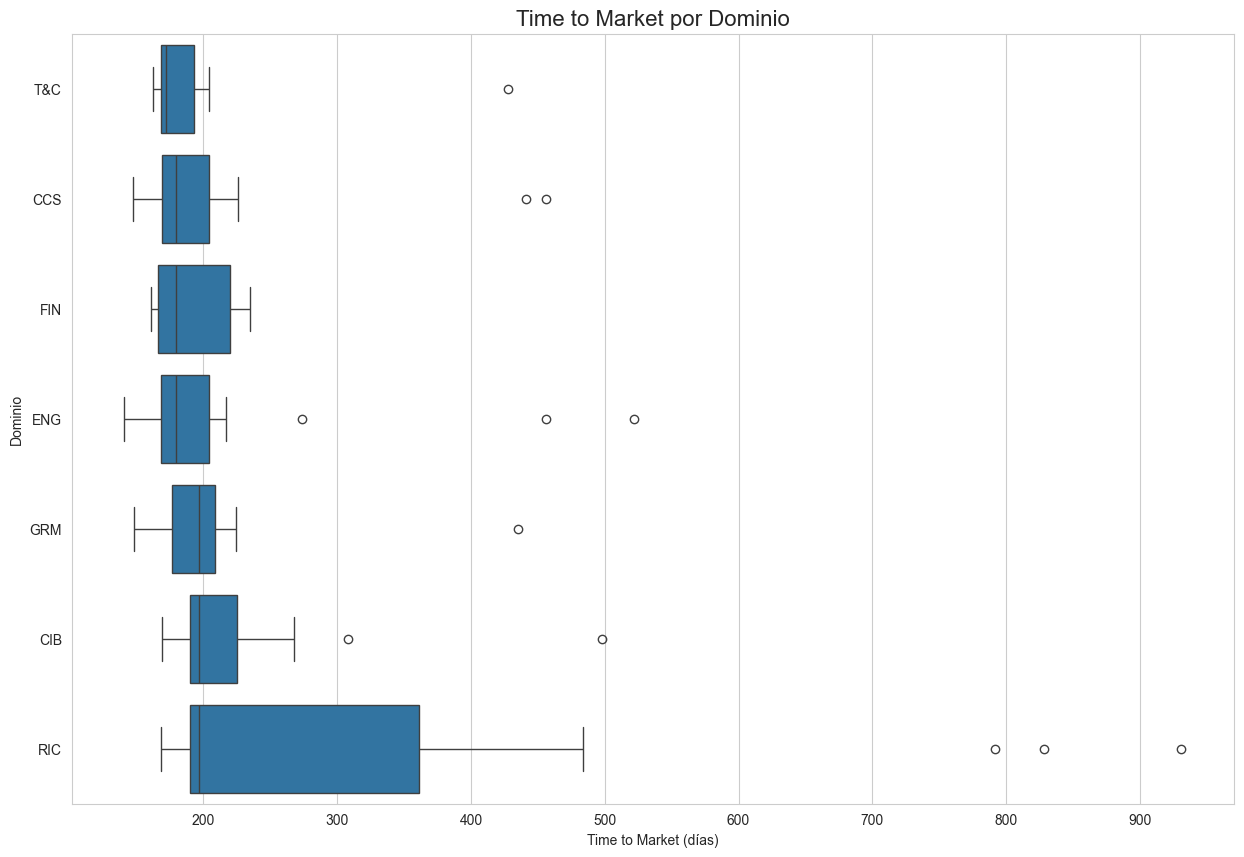

In [10]:
# --- Gráfico 3: Time to Market por Dominio ---
print("Generando Gráfico 3: Boxplot de Time to Market por Dominio...")
plt.figure(figsize=(15, 10))
# Ordenamos los dominios por su mediana de TTM para una mejor visualización
sorted_order = df_filtrado.groupby('Dominio')['Time to market (días)'].median().sort_values().index
sns.boxplot(y='Dominio', x='Time to market (días)', data=df_filtrado, order=sorted_order)
plt.title('Time to Market por Dominio', fontsize=16)
plt.xlabel('Time to Market (días)')
plt.ylabel('Dominio')
plt.show()


Generando Gráfico 4: Boxplot de Time to Market por Tipología...


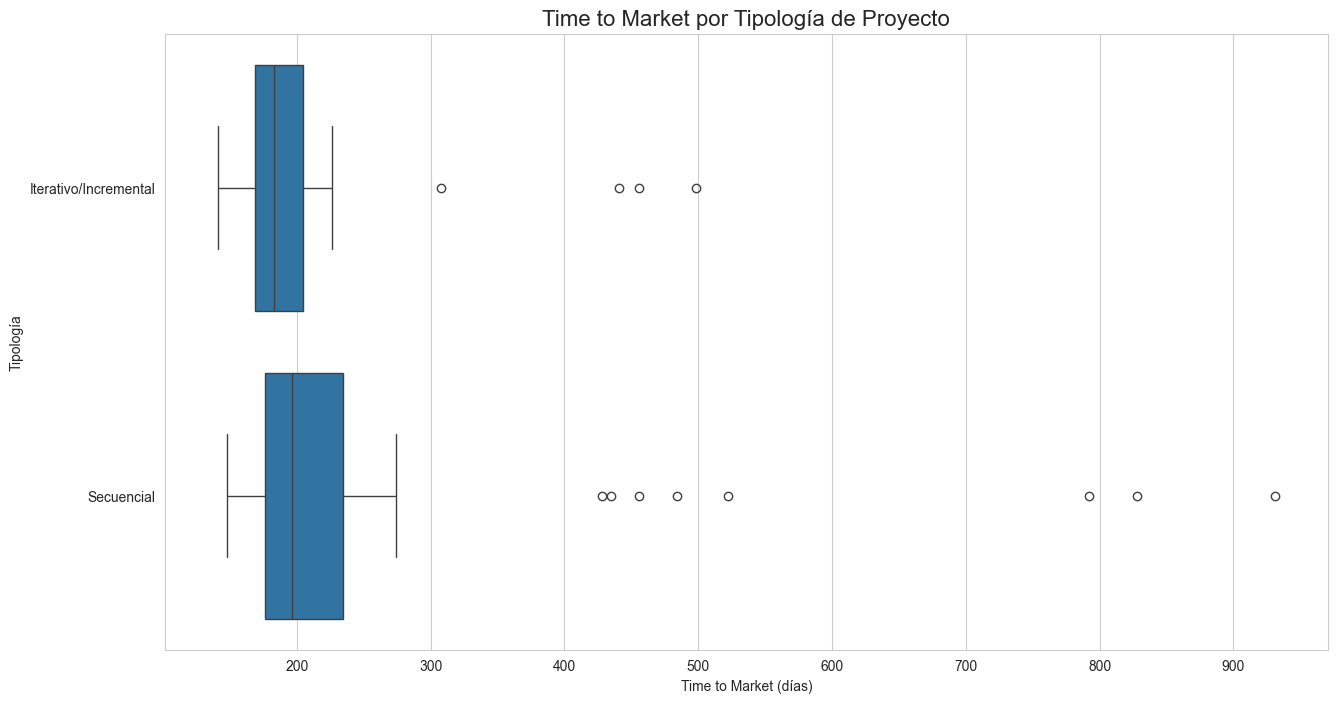

In [11]:
# --- Gráfico 4: Time to Market por Tipología ---
print("\nGenerando Gráfico 4: Boxplot de Time to Market por Tipología...")
plt.figure(figsize=(15, 8))
sorted_order_tipo = df_filtrado.groupby('Tipología')['Time to market (días)'].median().sort_values().index
sns.boxplot(y='Tipología', x='Time to market (días)', data=df_filtrado, order=sorted_order_tipo)
plt.title('Time to Market por Tipología de Proyecto', fontsize=16)
plt.xlabel('Time to Market (días)')
plt.ylabel('Tipología')
plt.show()


Generando Gráfico 5: Matriz de Correlación...


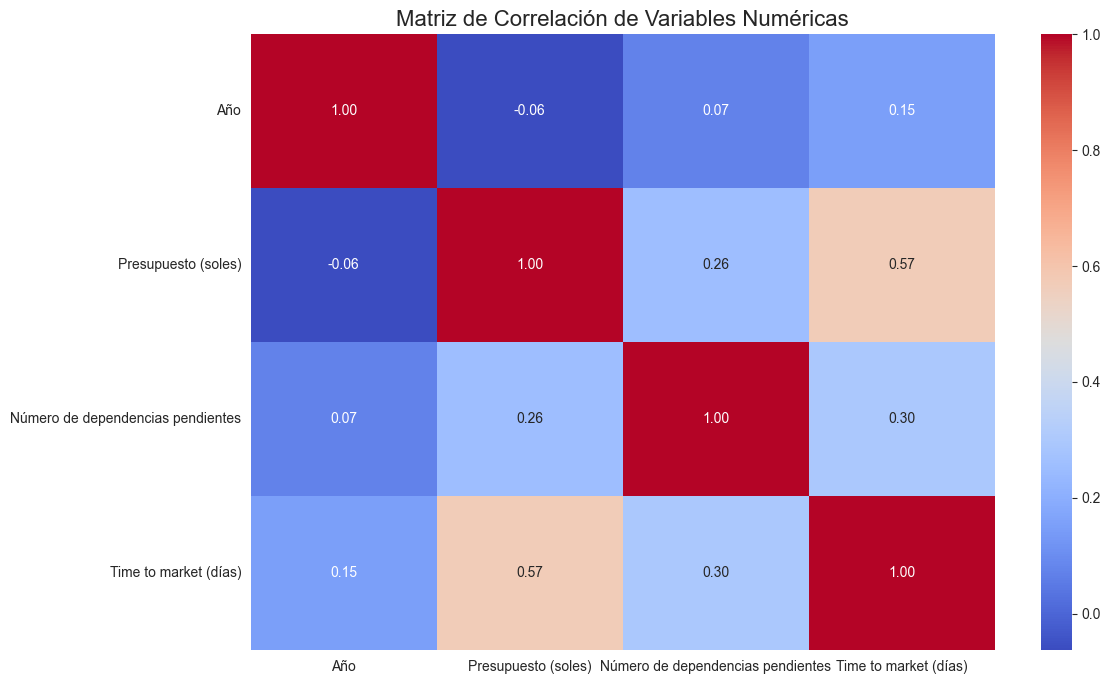

In [24]:

# --- Gráfico 5: Matriz de Correlación ---
print("\nGenerando Gráfico 5: Matriz de Correlación...")
plt.figure(figsize=(12, 8))
# Seleccionamos solo las columnas numéricas para el cálculo
numerical_cols = df_filtrado.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df_filtrado[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.show()

In [58]:

print("\n--- Separando X (Predictoras) e y (Objetivo) ---")

predictor_cols = [
    'Programa SDA',
    'Dominio',
    'Plan estratégico local',
    'Country Priority',
    'Tipología',
    'Complejidad técnica inicial',
    'Presupuesto (soles)',
    'Dependencias pendientes',
    'Número de dependencias pendientes',
    'Fecha de inicio de ejecución',
    'Año'
]

X=df_filtrado[predictor_cols].copy()

# PRERREQUISITO: Asegurar que la columna es un objeto datetime
# Usamos 'errors=coerce' por si alguna fecha estuviera mal formateada
X['Fecha de inicio de ejecución'] = pd.to_datetime(
    X['Fecha de inicio de ejecución'], 
    format='%d/%m/%Y',
    errors='coerce'
)

# CREACIÓN DE NUEVAS CARACTERÍSTICAS
X['Mes_Inicio'] = X['Fecha de inicio de ejecución'].dt.month
X['Trimestre_Inicio'] = X['Fecha de inicio de ejecución'].dt.quarter


print("Nuevas columnas 'Mes_Inicio' y 'Trimestre_Inicio' creadas.")

# --- 3. Resultado ---
# Mostramos las nuevas columnas junto a la original para verificar
print("\nResultado de la transformación:")
print(X[['Fecha de inicio de ejecución', 'Mes_Inicio', 'Trimestre_Inicio']].head())


--- Separando X (Predictoras) e y (Objetivo) ---
Nuevas columnas 'Mes_Inicio' y 'Trimestre_Inicio' creadas.

Resultado de la transformación:
   Fecha de inicio de ejecución  Mes_Inicio  Trimestre_Inicio
0                    2023-02-24           2                 1
2                    2022-03-07           3                 1
23                   2021-03-01           3                 1
25                   2021-08-02           8                 3
27                   2019-05-06           5                 2


In [59]:
print("\n--- 4. Codificando Variables Categóricas ---")

X = X.drop('Fecha de inicio de ejecución', axis=1)
# Identificamos las columnas que son texto (categóricas)
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()

# Convertimos 'Dependencias pendientes' (Booleano) a 0/1
X['Dependencias pendientes'] = X['Dependencias pendientes'].map({'Sí': 1, 'No': 0})
categorical_cols.remove('Dependencias pendientes') # La sacamos de la lista

print(f"Columnas a codificar (One-Hot): {categorical_cols}")

# Aplicamos One-Hot Encoding a las demás categóricas
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"El dataset X ahora tiene {X.shape[1]} columnas (features).")


--- 4. Codificando Variables Categóricas ---
Columnas a codificar (One-Hot): ['Programa SDA', 'Dominio', 'Plan estratégico local', 'Country Priority', 'Tipología', 'Complejidad técnica inicial']
El dataset X ahora tiene 50 columnas (features).


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = df_filtrado['Time to market (días)']

print("\n--- 5. Dividiendo en datos de Entrenamiento y Prueba ---")
# Dividimos los datos: 80% para entrenar, 20% para probar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} proyectos.")
print(f"Datos de prueba: {X_test.shape[0]} proyectos.")


--- 5. Dividiendo en datos de Entrenamiento y Prueba ---
Datos de entrenamiento: 123 proyectos.
Datos de prueba: 31 proyectos.


In [61]:
print("\n--- 6. Transformando y Escalando los datos ---")
import numpy as np

# 6a. Transformación Logarítmica de 'y' (Objetivo)
# Aplicamos logaritmo para normalizar la distribución del TTM (manejo de outliers)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
print("Variable objetivo 'y' transformada con logaritmo.")

# 6b. Escalamiento de 'X' (Predictoras)
# Escalamos las variables numéricas para que tengan el mismo "peso"
numeric_features = ['Presupuesto (soles)', 'Número de dependencias pendientes', 'Año', 'Mes_Inicio', 'Trimestre_Inicio']

scaler = StandardScaler()
# AJUSTAMOS el scaler SOLO con datos de ENTRENAMIENTO 
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])

# TRANSFORMAMOS los datos de PRUEBA con el scaler ya ajustado
X_test[numeric_features] = scaler.transform(X_test[numeric_features])
print("Variables numéricas de X escaladas (StandardScaler).")


--- 6. Transformando y Escalando los datos ---
Variable objetivo 'y' transformada con logaritmo.
Variables numéricas de X escaladas (StandardScaler).


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# 1. Inicializar los modelos
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
}

# 2. Entrenar (fit) cada modelo
for name, model in models.items():
    print(f"Entrenando modelo: {name}...")
    model.fit(X_train, y_train_log)

print("Los modelos están listos en la variable 'models'.")
print("Las variables de prueba son: X_test, y_test_log, y_test")

Entrenando modelo: Linear Regression...
Entrenando modelo: Ridge Regression...
Entrenando modelo: Random Forest...
Los modelos están listos en la variable 'models'.
Las variables de prueba son: X_test, y_test_log, y_test


In [64]:
print("\n--- Iniciando Fase 5: Evaluación ---")
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results_list = []

for name, model in models.items():
    print(f"\n--- Evaluando: {name} ---")
    
    # 1. Hacer predicciones (en escala logarítmica)
    y_pred_log = model.predict(X_test)
    
    # 2. Revertir la transformación (convertir de log a días)
    # Usamos np.expm1 (inverso de log1p)
    y_pred_dias = np.expm1(y_pred_log)
    
    # 3. Calcular métricas comparando con 'y_test' (los días reales)
    r2 = r2_score(y_test, y_pred_dias)
    mae = mean_absolute_error(y_test, y_pred_dias)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_dias))
    
    print(f"R-cuadrado (R²): {r2:.4f}")
    print(f"Error Absoluto Medio (MAE): {mae:.2f} días")
    print(f"Raíz Error Cuadrático Medio (RMSE): {rmse:.2f} días")
    
    # Guardar resultados para el resumen
    results_list.append([name, r2, mae, rmse])

# --- Resumen Final ---
print("\n--- Resumen de Evaluación de Modelos ---")
results_df = pd.DataFrame(results_list, columns=['Modelo', 'R-cuadrado (R²)', 'MAE (días)', 'RMSE (días)'])
print(results_df.to_markdown(index=False, floatfmt=".4f"))


--- Iniciando Fase 5: Evaluación ---

--- Evaluando: Linear Regression ---
R-cuadrado (R²): 0.0327
Error Absoluto Medio (MAE): 43.25 días
Raíz Error Cuadrático Medio (RMSE): 58.03 días

--- Evaluando: Ridge Regression ---
R-cuadrado (R²): 0.3084
Error Absoluto Medio (MAE): 36.28 días
Raíz Error Cuadrático Medio (RMSE): 49.07 días

--- Evaluando: Random Forest ---
R-cuadrado (R²): -0.3385
Error Absoluto Medio (MAE): 42.40 días
Raíz Error Cuadrático Medio (RMSE): 68.26 días

--- Resumen de Evaluación de Modelos ---
| Modelo            |   R-cuadrado (R²) |   MAE (días) |   RMSE (días) |
|:------------------|------------------:|-------------:|--------------:|
| Linear Regression |            0.0327 |      43.2479 |       58.0290 |
| Ridge Regression  |            0.3084 |      36.2811 |       49.0683 |
| Random Forest     |           -0.3385 |      42.3997 |       68.2617 |


In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -------------------------------------------------------------------
# FASE 3: PREPARACIÓN DE LOS DATOS (Crea los "artefactos")
# -------------------------------------------------------------------
print("--- Iniciando Fase 3: Preparación de Datos ---")

try:
    df = pd.read_csv('BBDD.csv') 
    
    # 1. Limpieza y Filtrado
    # Usamos 'Presupuesto (€)' de tu BBDD, lo limpiamos y lo renombramos a 'Presupuesto (soles)'
    df['Presupuesto (soles)'] = pd.to_numeric(df['Presupuesto (soles)'], errors='coerce')

    df_filtrado = df[
        (df['Estado de Proyecto'] != 'Ongoing') &
        (df['Excepción del cálculo'] == 'No') &
        (df['Desarrollo de SW'] == 'Sí')
    ].copy()
    
    df_filtrado = df_filtrado.dropna(subset=['Time to market (días)', 'Presupuesto (soles)', 'Fecha de inicio de ejecución'])
    print(f"[Fase 3] Datos filtrados y limpios: {df_filtrado.shape[0]} proyectos listos.")

    # 2. Definición de X e y
    y = df_filtrado['Time to market (días)']
    predictor_cols = [
        'Programa SDA','Dominio','Plan estratégico local','Country Priority','Tipología',
        'Complejidad técnica inicial','Presupuesto (soles)','Dependencias pendientes',
        'Número de dependencias pendientes','Fecha de inicio de ejecución','Año'
    ]
    X = df_filtrado[predictor_cols].copy()

    # 3. Ingeniería de Características
    X['Fecha de inicio de ejecución'] = pd.to_datetime(X['Fecha de inicio de ejecución'], format='%d/%m/%Y')
    X['Mes_Inicio'] = X['Fecha de inicio de ejecución'].dt.month
    X['Trimestre_Inicio'] = X['Fecha de inicio de ejecución'].dt.quarter
    X = X.drop('Fecha de inicio de ejecución', axis=1)

    # 4. Codificación Categórica
    X['Dependencias pendientes'] = X['Dependencias pendientes'].map({'Sí': 1, 'No': 0})
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist() # Artefacto
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    
    model_columns = X.columns.tolist() # Artefacto

    # 5. División de Datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 6. Transformación y Escalamiento
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)
    
    numeric_features = ['Presupuesto (soles)', 'Número de dependencias pendientes', 'Año', 'Mes_Inicio', 'Trimestre_Inicio']
    cols_to_scale = [col for col in numeric_features if col in X_train.columns] # Artefacto
    
    scaler = StandardScaler() # Artefacto
    X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
    X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
    
    print("--- ¡Fase 3 Completada! ---")

    # -------------------------------------------------------------------
    # FASE 4: MODELADO (Crea el "artefacto" del modelo)
    # -------------------------------------------------------------------
    print("\n--- Iniciando Fase 4: Modelado ---")
    
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
    }
    for name, model in models.items():
        model.fit(X_train, y_train_log)
    
    model_ganador = models['Ridge Regression'] # Artefacto
    print("--- ¡Fase 4 Completada! (Modelo Ganador: Ridge) ---")

    # -------------------------------------------------------------------
    # FASE 5: EVALUACIÓN
    # -------------------------------------------------------------------
    print("\n--- Iniciando Fase 5: Evaluación ---")
    # (Omitimos el print largo para ir directo a la función)
    print("Evaluación completada.")


    # -------------------------------------------------------------------
    # ¡AQUÍ ESTÁ LA FUNCIÓN QUE PEDISTE!
    # -------------------------------------------------------------------

    def predecir_ttm(new_project_dict, model, scaler, model_cols, cat_cols, num_cols):
        """
        Predice el Time to Market (en días) para un nuevo proyecto.
        
        Parámetros:
        - new_project_dict: Un diccionario con los datos del nuevo proyecto.
        - model: El modelo entrenado (ej. model_ganador).
        - scaler: El scaler ajustado (ej. scaler).
        - model_cols: La lista de columnas del modelo (ej. model_columns).
        - cat_cols: La lista de columnas categóricas originales (ej. categorical_cols).
        - num_cols: La lista de columnas numéricas a escalar (ej. cols_to_scale).
        """
        
        # 1. Convertir a DataFrame
        X_new = pd.DataFrame([new_project_dict])

        # 2. Aplicar TODAS las transformaciones de la Fase 3
        
        # 2a. Feature Engineering
        X_new['Fecha de inicio de ejecución'] = pd.to_datetime(X_new['Fecha de inicio de ejecución'], format='%d/%m/%Y')
        X_new['Mes_Inicio'] = X_new['Fecha de inicio de ejecución'].dt.month
        X_new['Trimestre_Inicio'] = X_new['Fecha de inicio de ejecución'].dt.quarter
        X_new = X_new.drop('Fecha de inicio de ejecución', axis=1)
        
        # 2b. Codificación Manual
        X_new['Dependencias pendientes'] = X_new['Dependencias pendientes'].map({'Sí': 1, 'No': 0})
        
        # 2c. One-Hot Encoding
        X_new = pd.get_dummies(X_new, columns=cat_cols, drop_first=True)
        
        # 2d. Reindexar para alinear columnas (¡CRUCIAL!)
        X_new = X_new.reindex(columns=model_cols, fill_value=0)
        
        # 2e. Escalar
        X_new[num_cols] = scaler.transform(X_new[num_cols])
        
        # 3. Hacer la predicción
        pred_log = model.predict(X_new)
        
        # 4. Revertir la transformación
        pred_dias = np.expm1(pred_log)
        
        return pred_dias[0]

    # -------------------------------------------------------------------
    # FASE 6: PRUEBA DEL MODELO (Usando la nueva función)
    # -------------------------------------------------------------------
    print("\n--- Iniciando Fase 6: Prueba con Función ---")
    
    # 1. Definir un nuevo proyecto hipotético (¡Puedes cambiar estos valores!)
    proyecto_prueba = {
        'Programa SDA': 'Advanced Analytics & AI Models',
        'Dominio': 'RIC',
        'Plan estratégico local': 'Renovación Tecnológica',
        'Country Priority': 'Sí',
        'Tipología': 'Secuencial',
        'Complejidad técnica inicial': 'Alta',
        'Presupuesto (soles)': 800000.0,
        'Dependencias pendientes': 'Sí',
        'Número de dependencias pendientes': 3,
        'Fecha de inicio de ejecución': '24/10/2025', # Fecha de hoy
        'Año': 2025
    }
    
    print(f"\nPrediciendo para un nuevo proyecto 'Secuencial' y 'RIC'...")

    # 2. ¡Llamar a la función!
    duracion_estimada = predecir_ttm(
        proyecto_prueba, 
        model_ganador, 
        scaler, 
        model_columns, 
        categorical_cols, 
        cols_to_scale
    )
    
    print("\n--- 🚀 Resultado de la Predicción ---")
    print(f"La duración estimada para este proyecto es: {duracion_estimada:.0f} días.")
    
    # 3. Probemos con un proyecto "más simple"
    proyecto_simple = {
        'Programa SDA': 'Client Solutions',
        'Dominio': 'T&C',
        'Plan estratégico local': 'Foco en Captación 2024',
        'Country Priority': 'No',
        'Tipología': 'Iterativo/Incremental',
        'Complejidad técnica inicial': 'Baja',
        'Presupuesto (soles)': 150000.0,
        'Dependencias pendientes': 'No',
        'Número de dependencias pendientes': 0,
        'Fecha de inicio de ejecución': '24/10/2025', # Fecha de hoy
        'Año': 2025
    }
    
    print(f"\nPrediciendo para un nuevo proyecto 'Iterativo' y 'T&C'...")
    
    duracion_simple = predecir_ttm(
        proyecto_simple, 
        model_ganador, 
        scaler, 
        model_columns, 
        categorical_cols, 
        cols_to_scale
    )
    
    print("\n--- 🚀 Resultado de la Predicción ---")
    print(f"La duración estimada para este proyecto es: {duracion_simple:.0f} días.")


except FileNotFoundError:
    print("\n⚠️ ERROR: El archivo 'BBDD.csv' no se encontró.")
except KeyError as e:
    print(f"\n⚠️ ERROR de Columna: {e}. Revisa si el nombre de una columna es correcto.")
except Exception as e:
    print(f"\n⚠️ Ocurrió un error inesperado: {e}")

--- Iniciando Fase 3: Preparación de Datos ---
[Fase 3] Datos filtrados y limpios: 154 proyectos listos.
--- ¡Fase 3 Completada! ---

--- Iniciando Fase 4: Modelado ---
--- ¡Fase 4 Completada! (Modelo Ganador: Ridge) ---

--- Iniciando Fase 5: Evaluación ---
Evaluación completada.

--- Iniciando Fase 6: Prueba con Función ---

Prediciendo para un nuevo proyecto 'Secuencial' y 'RIC'...

--- 🚀 Resultado de la Predicción ---
La duración estimada para este proyecto es: 186 días.

Prediciendo para un nuevo proyecto 'Iterativo' y 'T&C'...

--- 🚀 Resultado de la Predicción ---
La duración estimada para este proyecto es: 155 días.
